## Analysis Dataset

In [113]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# dataset path
dataset_path = r'dataset'

data_set = os.listdir(dataset_path)

In [114]:
len(data_set)

47

# handle issue

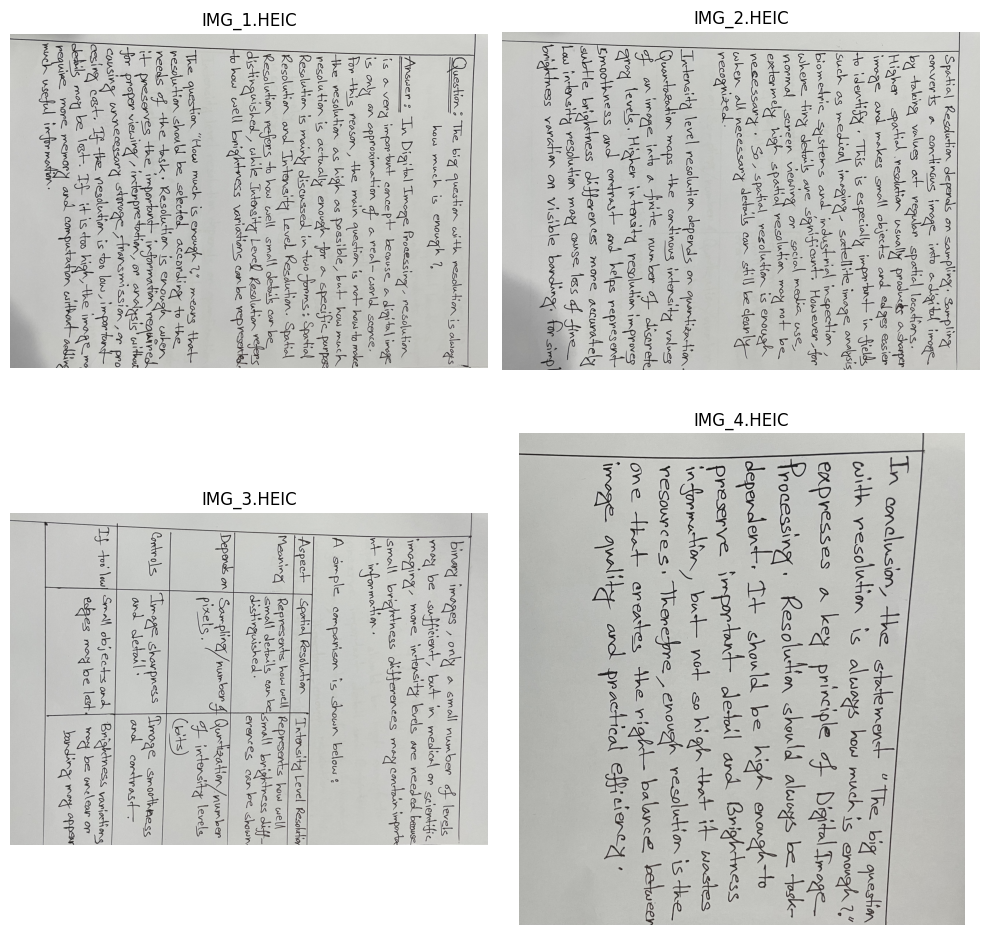

In [115]:
import warnings
import imageio
warnings.filterwarnings('ignore', category=DeprecationWarning)

folder = r'dataset\223311016'
images = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png', '.heic'))]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for idx, img_name in enumerate(images[:4]):
    img = imageio.imread(os.path.join(folder, img_name))
    axes[idx].imshow(img)
    axes[idx].set_title(img_name)
    axes[idx].axis('off')

plt.tight_layout()
# plt.show()

# Mid-Level Image Processing

In [116]:
# Filter folders with exactly 5 images
folders_with_5_images = []

for folder_name in data_set:
    folder_path = os.path.join(dataset_path, folder_name)
    if os.path.isdir(folder_path):
        # Count image files in the folder
        img_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg', '.heic', '.gif', '.bmp'))]
        if len(img_files) == 5:
            folders_with_5_images.append(folder_name)

In [117]:
folders_with_5_images

['201311077',
 '201311192',
 '221311105',
 '221311193',
 '221311194',
 '222311062',
 '222311075',
 '223311004',
 '223311008',
 '223311009',
 '223311010',
 '223311014',
 '223311022',
 '223311028']

In [118]:
import cv2
from scipy import ndimage
from skimage import morphology, filters, feature, exposure, segmentation
from sklearn.cluster import KMeans

# Define all available techniques
available_techniques = {
    'Laplacian Filtering': 'laplacian',
    'Gabor Filtering': 'gabor',
    'Morphological Processing': 'morphological',
    'Skeletonization': 'skeletonization',
    'K-Means Segmentation': 'kmeans',
    'Histogram Equalization': 'histogram_eq',
    'Sharpening Filter': 'sharpening',
    'Gaussian Blur': 'gaussian_blur',
    'Canny Edge Detector': 'canny',
    'Sobel Operator': 'sobel'
}

# Students select 5 techniques
selected_techniques = ['Laplacian Filtering', 'Gabor Filtering', 'Morphological Processing', 
                       'Skeletonization', 'K-Means Segmentation']

# Function to apply each technique
def apply_laplacian(img):
    """Apply Laplacian filtering"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    laplacian = np.uint8(np.clip(laplacian, 0, 255))
    return laplacian

def apply_gabor(img):
    """Apply Gabor filtering"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getGaborKernel((21, 21), 3, np.pi/4, 10, 0.5, 0)
    filtered = cv2.filter2D(gray, -1, kernel)
    filtered = np.uint8(np.clip(filtered, 0, 255))
    return filtered

def apply_morphological(img):
    """Apply morphological processing (opening)"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    opened = cv2.morphologyEx(gray, cv2.MORPH_OPEN, kernel)
    return opened

def apply_skeletonization(img):
    """Apply skeletonization"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    skeleton = morphology.skeletonize(binary // 255)
    return np.uint8(skeleton * 255)

def apply_kmeans(img):
    """Apply K-Means segmentation"""
    data = img.reshape((-1, 3))
    data = np.float32(data)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(data, 5, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    result = centers[labels.flatten()]
    return result.reshape(img.shape)

def apply_histogram_eq(img):
    """Apply histogram equalization"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    equalized = cv2.equalizeHist(gray)
    return equalized

def apply_sharpening(img):
    """Apply sharpening filter"""
    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]]) / 1.0
    sharpened = cv2.filter2D(img, -1, kernel)
    return np.uint8(np.clip(sharpened, 0, 255))

def apply_gaussian_blur(img):
    """Apply Gaussian blur"""
    blurred = cv2.GaussianBlur(img, (15, 15), 0)
    gray = cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY)
    return gray

def apply_canny(img):
    """Apply Canny edge detector"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    canny = cv2.Canny(gray, 100, 200)
    return canny

def apply_sobel(img):
    """Apply Sobel operator"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
    magnitude = np.sqrt(sobelx**2 + sobely**2)
    magnitude = np.uint8(np.clip(magnitude, 0, 255))
    return magnitude

# Map technique names to functions
technique_functions = {
    'Laplacian Filtering': apply_laplacian,
    'Gabor Filtering': apply_gabor,
    'Morphological Processing': apply_morphological,
    'Skeletonization': apply_skeletonization,
    'K-Means Segmentation': apply_kmeans,
    'Histogram Equalization': apply_histogram_eq,
    'Sharpening Filter': apply_sharpening,
    'Gaussian Blur': apply_gaussian_blur,
    'Canny Edge Detector': apply_canny,
    'Sobel Operator': apply_sobel
}


In [119]:
selected_techniques

['Laplacian Filtering',
 'Gabor Filtering',
 'Morphological Processing',
 'Skeletonization',
 'K-Means Segmentation']

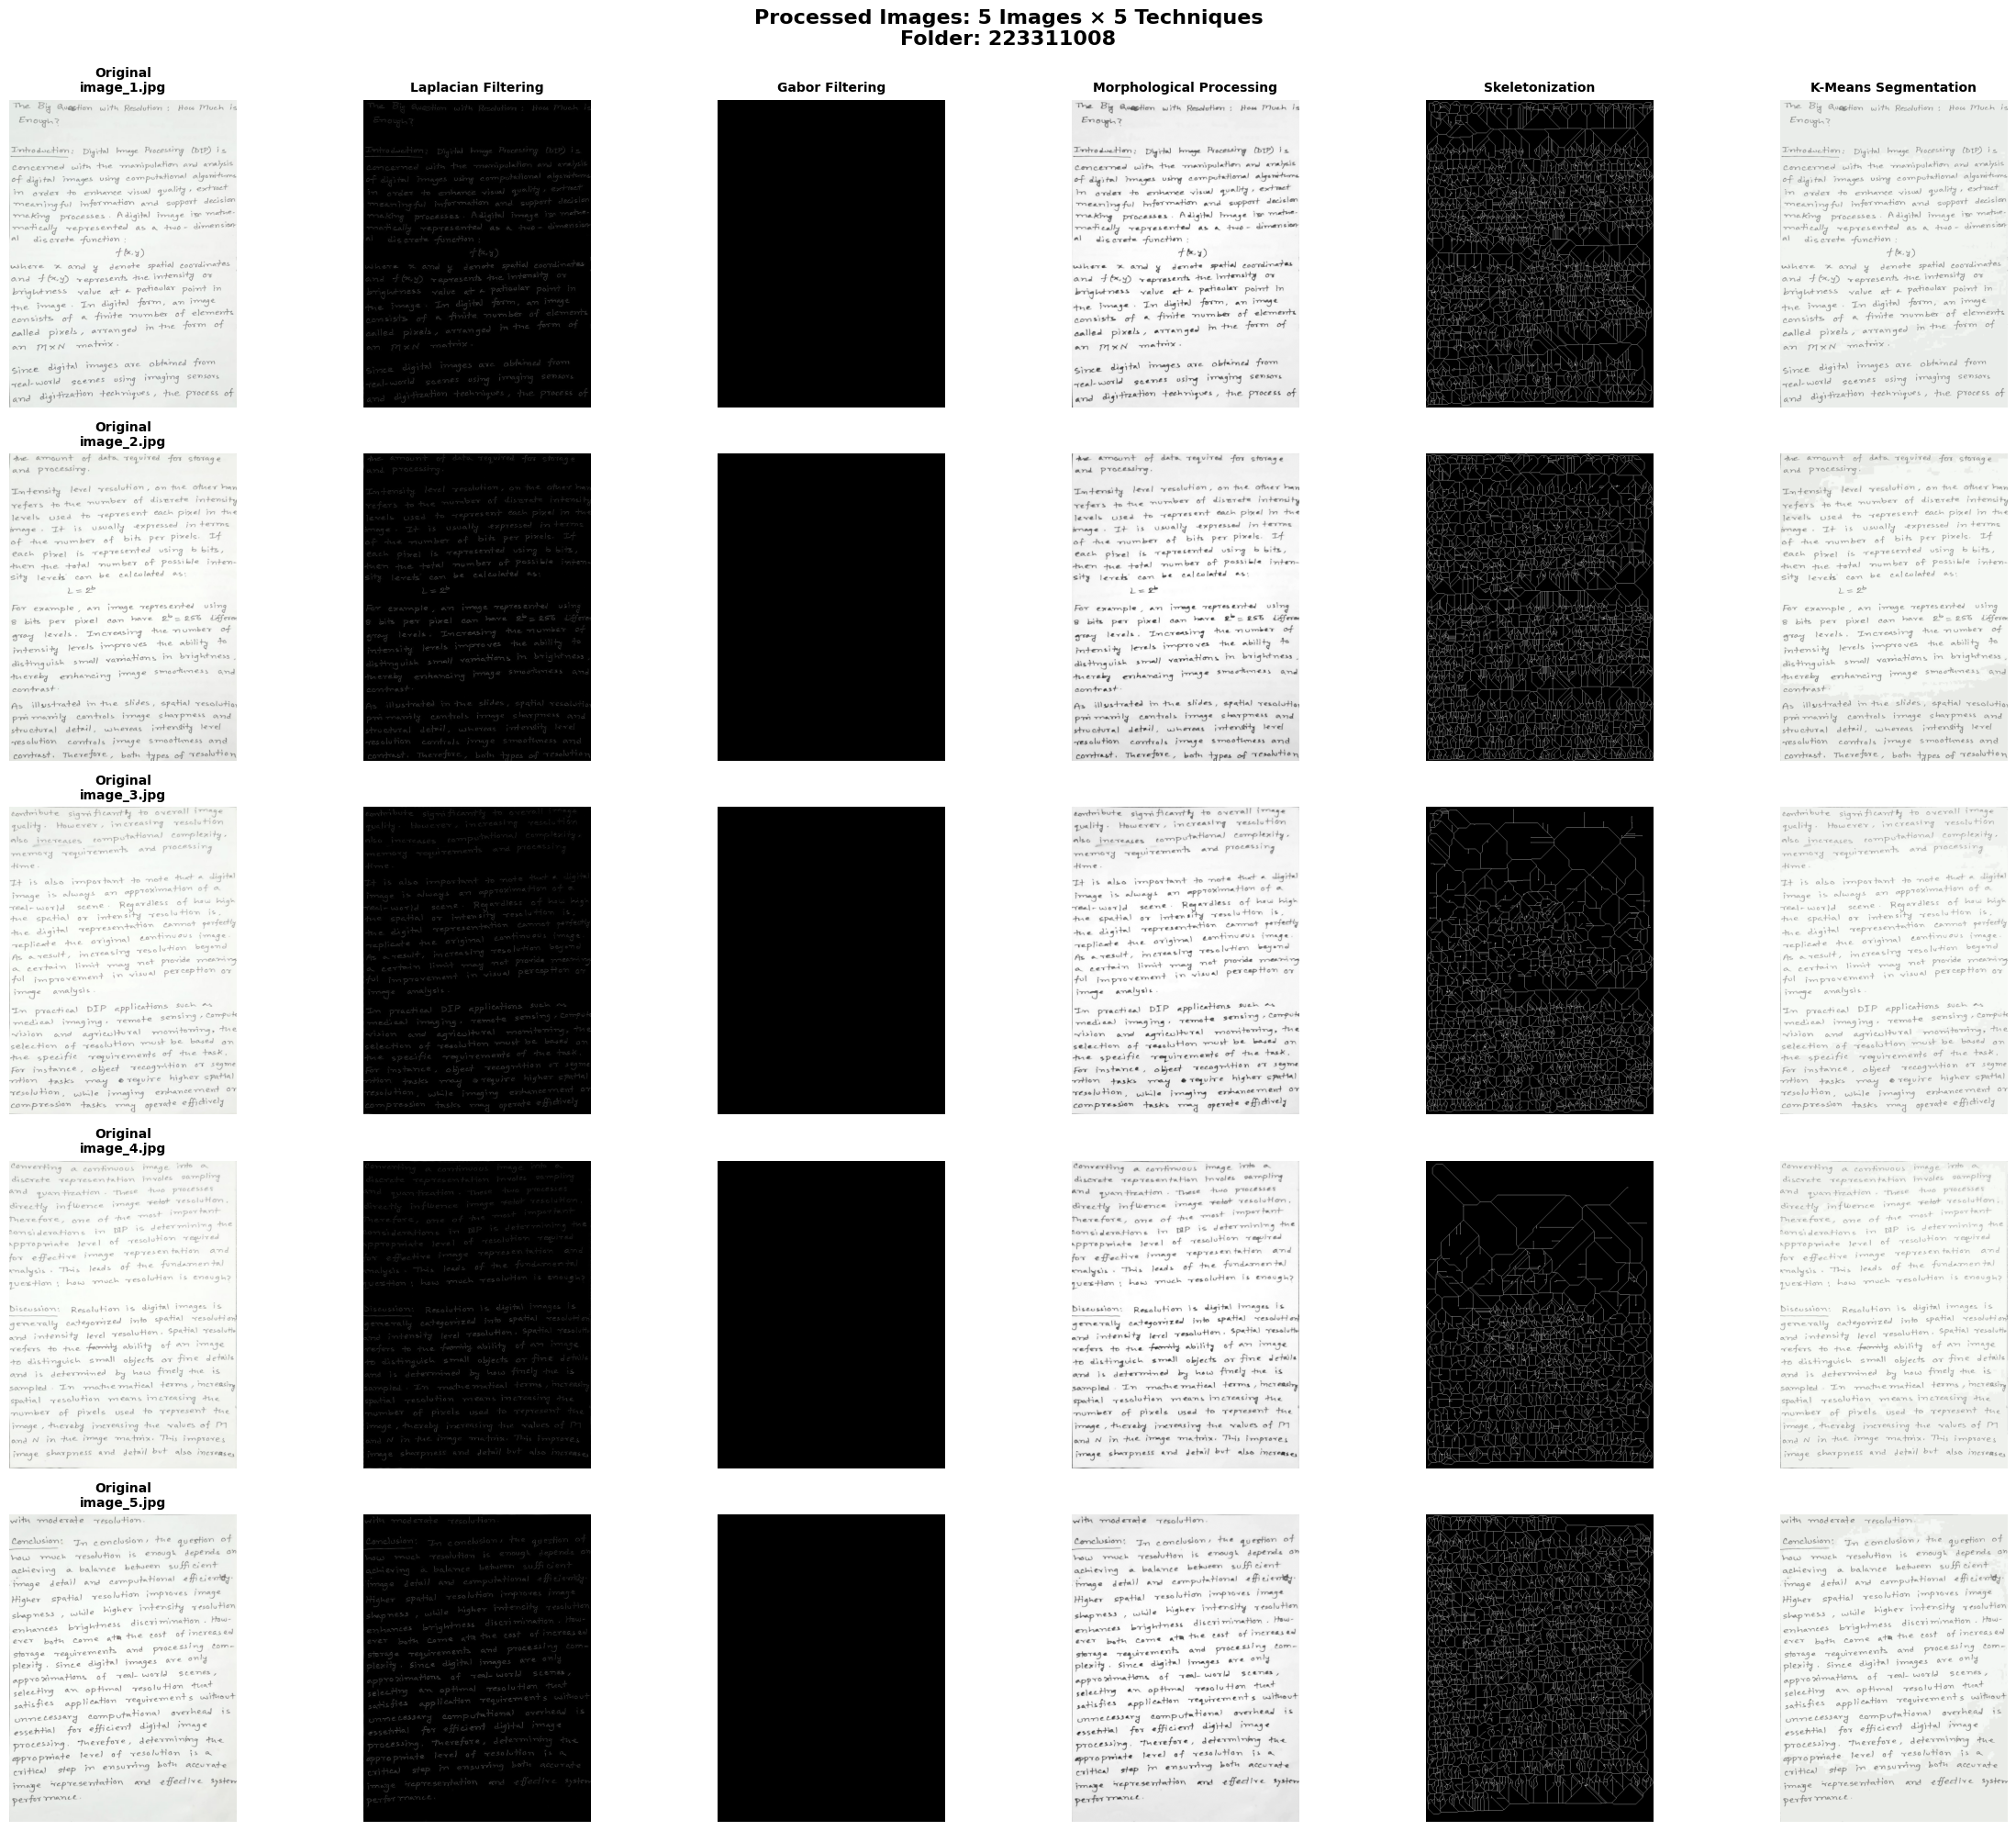

In [120]:
# Select one of the folders with exactly 5 images
selected_folder = folders_with_5_images[8]
folder_path = os.path.join(dataset_path, selected_folder)

# Load all images from the folder
original_images_list = []
image_names = []
img_files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg', '.heic', '.gif', '.bmp'))])

for img_file in img_files:
    img_path = os.path.join(folder_path, img_file)
    img = cv2.imread(img_path)
    if img is not None:
        original_images_list.append(img)
        image_names.append(img_file)

# Display all processed images in a dynamic grid
fig, axes = plt.subplots(len(original_images_list), len(selected_techniques) + 1, figsize=(24, 20))

# For each original image
for img_idx, original_img in enumerate(original_images_list):
    # Show original image in first column
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    axes[img_idx, 0].imshow(original_img_rgb)
    axes[img_idx, 0].set_title(f'Original\n{image_names[img_idx]}', fontweight='bold', fontsize=10)
    axes[img_idx, 0].axis('off')
    
    # Apply each technique to this image
    for tech_idx, technique_name in enumerate(selected_techniques):
        technique_func = technique_functions[technique_name]
        processed = technique_func(original_img)
        
        # Display processed image
        if len(processed.shape) == 3:  # Color image
            processed_rgb = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
            axes[img_idx, tech_idx + 1].imshow(processed_rgb)
        else:  # Grayscale image
            axes[img_idx, tech_idx + 1].imshow(processed, cmap='gray')
        
        # Add title only for first row
        if img_idx == 0:
            axes[img_idx, tech_idx + 1].set_title(technique_name, fontweight='bold', fontsize=10)
        
        axes[img_idx, tech_idx + 1].axis('off')

fig.suptitle(f'Processed Images: {len(original_images_list)} Images × {len(selected_techniques)} Techniques\nFolder: {selected_folder}', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Image Augmentation
Augment processed images using 4 techniques to generate 100 final images (25 × 4)

In [121]:
from scipy import ndimage

# Define augmentation techniques
augmentation_techniques = {
    'Random Rotation': 'random_rotation',
    'Random Horizontal Translation': 'random_translation',
    'Gaussian Noise Injection': 'gaussian_noise',
    'Random Sharpness Adjustment': 'random_sharpness',
    'Elastic Distortion': 'elastic_distortion'
}

# Students select 4 augmentations
selected_augmentations = ['Random Rotation', 'Random Horizontal Translation', 
                          'Gaussian Noise Injection', 'Elastic Distortion']

# Augmentation functions
def apply_random_rotation(img):
    """Apply random rotation"""
    angle = np.random.randint(-15, 16)
    if len(img.shape) == 3:
        return ndimage.rotate(img, angle, axes=(0, 1), reshape=False).astype(np.uint8)
    else:
        return ndimage.rotate(img, angle, reshape=False).astype(np.uint8)

def apply_random_translation(img):
    """Apply random horizontal translation"""
    shift = np.random.randint(-10, 11)
    if len(img.shape) == 3:
        return ndimage.shift(img, (0, shift, 0), mode='constant', cval=0).astype(np.uint8)
    else:
        return ndimage.shift(img, shift, mode='constant', cval=0).astype(np.uint8)

def apply_gaussian_noise(img):
    """Apply Gaussian noise injection"""
    noise = np.random.normal(0, 25, img.shape)
    noisy_img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy_img

def apply_random_sharpness(img):
    """Apply random sharpness adjustment"""
    # Create sharpening kernel
    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]]) / np.random.uniform(0.5, 1.5)
    
    if len(img.shape) == 3:
        # Apply to each channel
        sharpened = cv2.filter2D(img, -1, kernel)
    else:
        sharpened = cv2.filter2D(img, -1, kernel)
    
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def apply_elastic_distortion(img):
    """Apply elastic distortion"""
    alpha = 30
    sigma = 5
    random_state = np.random.RandomState()
    
    if len(img.shape) == 3:
        h, w, c = img.shape
    else:
        h, w = img.shape
        c = 1
    
    # Generate random displacement fields
    dx = random_state.randn(h, w) * sigma
    dy = random_state.randn(h, w) * sigma
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    # Apply elastic distortion
    indices = np.reshape(y + dy * alpha, (-1, 1)), np.reshape(x + dx * alpha, (-1, 1))
    
    if len(img.shape) == 3:
        distorted = np.zeros_like(img)
        for channel in range(c):
            distorted[:,:,channel] = ndimage.map_coordinates(img[:,:,channel], indices, order=1, cval=0).reshape(h, w)
    else:
        distorted = ndimage.map_coordinates(img, indices, order=1, cval=0).reshape(h, w)
    
    return distorted.astype(np.uint8)

# Map augmentation names to functions
augmentation_functions = {
    'Random Rotation': apply_random_rotation,
    'Random Horizontal Translation': apply_random_translation,
    'Gaussian Noise Injection': apply_gaussian_noise,
    'Random Sharpness Adjustment': apply_random_sharpness,
    'Elastic Distortion': apply_elastic_distortion
}
print(f"Selected augmentations: {len(selected_augmentations)}")

Selected augmentations: 4


## Apply Augmentations to 25 Processed Images

In [122]:
# Generate 25 processed images and apply 4 augmentation
print("APPLYING AUGMENTATIONS TO PROCESSED IMAGES".center(70))

# Generate 25 processed images from 5 original × 5 techniques
print("\n[STEP 1] Generating 25 processed images...")
processed_images_list = []
processed_image_info = []

for img_idx, original_img in enumerate(original_images_list):
    for tech_idx, technique_name in enumerate(selected_techniques):
        technique_func = technique_functions[technique_name]
        processed = technique_func(original_img)
        processed_images_list.append(processed)
        processed_image_info.append({
            'original': image_names[img_idx],
            'technique': technique_name,
            'index': len(processed_images_list) - 1
        })

print(f"Generated {len(processed_images_list)} processed images")

# Apply 4 augmentations to each processed image
print("\n[STEP 2] Applying {0} augmentations to each processed image...".format(len(selected_augmentations)))
augmented_images_list = []
augmentation_info = []

for proc_idx, processed_img in enumerate(processed_images_list):
    original_info = processed_image_info[proc_idx]
    
    for aug_idx, augmentation_name in enumerate(selected_augmentations):
        aug_func = augmentation_functions[augmentation_name]
        try:
            augmented = aug_func(processed_img)
            augmented_images_list.append(augmented)
            augmentation_info.append({
                'original': original_info['original'],
                'technique': original_info['technique'],
                'augmentation': augmentation_name,
                'index': len(augmented_images_list) - 1
            })
        except Exception as e:
            print(f"   Error in {augmentation_name}: {str(e)[:50]}")

print(f"Generated {len(augmented_images_list)} augmented images")

# Summary
print("\n")
print(f"PROCESSING COMPLETE")
print(f"  • Processed images: {len(processed_images_list)} ({len(original_images_list)} × {len(selected_techniques)})")
print(f"  • Augmented images: {len(augmented_images_list)} ({len(processed_images_list)} × {len(selected_augmentations)})")
print(f"  • Total dataset: {len(augmented_images_list)} images ready")

              APPLYING AUGMENTATIONS TO PROCESSED IMAGES              

[STEP 1] Generating 25 processed images...
Generated 25 processed images

[STEP 2] Applying 4 augmentations to each processed image...
Generated 100 augmented images


PROCESSING COMPLETE
  • Processed images: 25 (5 × 5)
  • Augmented images: 100 (25 × 4)
  • Total dataset: 100 images ready


## Visualize Augmented Dataset Samples

                VISUALIZING AUGMENTED DATASET SAMPLES                 

Displaying 3 processed images with 4 augmentations each...


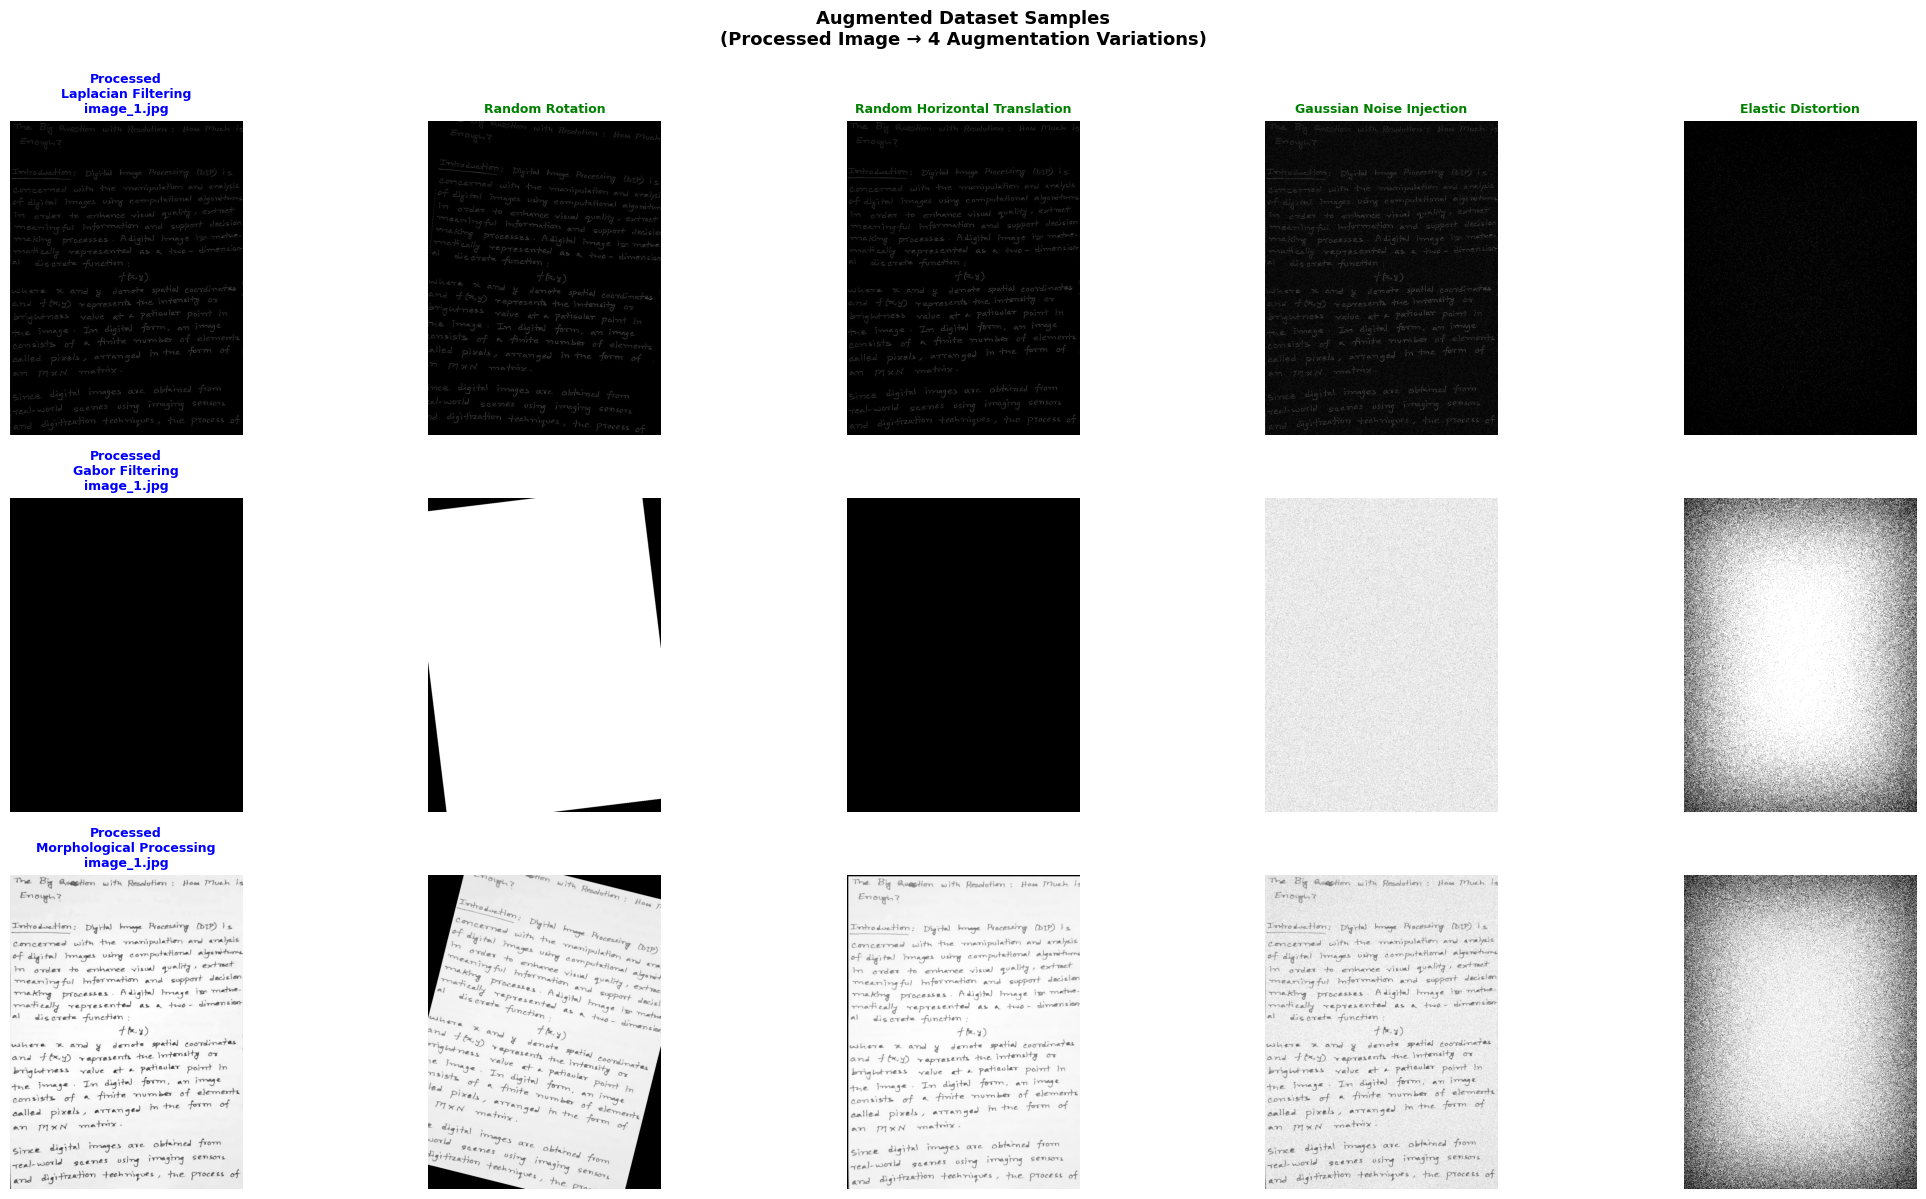


 Visualization complete!

Sample Statistics:
  • Samples shown: 3 processed images
  • Augmentations per sample: 4
  • Total augmented images available: 100


In [123]:
# Display sample augmented images (3 processed × 4 augmentations)

print("VISUALIZING AUGMENTED DATASET SAMPLES".center(70))


sample_processed = min(3, len(processed_images_list))
fig, axes = plt.subplots(sample_processed, len(selected_augmentations) + 1, figsize=(22, 12))

print(f"\nDisplaying {sample_processed} processed images with {len(selected_augmentations)} augmentations each...")

for proc_idx in range(sample_processed):
    processed_img = processed_images_list[proc_idx]
    info = processed_image_info[proc_idx]
    
    # Display processed image (original for this row)
    if len(processed_img.shape) == 3:
        axes[proc_idx, 0].imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))
    else:
        axes[proc_idx, 0].imshow(processed_img, cmap='gray')
    
    axes[proc_idx, 0].set_title(f'Processed\n{info["technique"]}\n{info["original"]}', 
                                 fontsize=9, fontweight='bold', color='blue')
    axes[proc_idx, 0].axis('off')
    
    # Display augmented versions
    for aug_idx, aug_name in enumerate(selected_augmentations):
        aug_list_idx = proc_idx * len(selected_augmentations) + aug_idx
        augmented = augmented_images_list[aug_list_idx]
        
        if len(augmented.shape) == 3:
            axes[proc_idx, aug_idx + 1].imshow(cv2.cvtColor(augmented, cv2.COLOR_BGR2RGB))
        else:
            axes[proc_idx, aug_idx + 1].imshow(augmented, cmap='gray')
        
        if proc_idx == 0:
            axes[proc_idx, aug_idx + 1].set_title(aug_name, fontsize=9, fontweight='bold', color='green')
        
        axes[proc_idx, aug_idx + 1].axis('off')

fig.suptitle('Augmented Dataset Samples\n(Processed Image → 4 Augmentation Variations)', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"\n Visualization complete!")
print(f"\nSample Statistics:")
print(f"  • Samples shown: {sample_processed} processed images")
print(f"  • Augmentations per sample: {len(selected_augmentations)}")
print(f"  • Total augmented images available: {len(augmented_images_list)}")

# Model Development

## Data Preparation for Model Training

In [133]:
# Prepare dataset for model training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import time

print("=" * 70)
print("PREPARING DATASET FOR TRAINING".center(70))
print("=" * 70)

# Create labels for augmented dataset (writer ID = folder index)
labels = []
for aug_info in augmentation_info:
    # Extract writer ID from folder name (find in folders_with_5_images)
    writer_id = folders_with_5_images.index(selected_folder)
    labels.append(writer_id)

labels = np.array(labels)

print(f"\n[1] Creating labels...")
print(f"   • Total images: {len(augmented_images_list)}")
print(f"   • Writer ID (folder index): {labels[0]}")
print(f"   • Unique writers in this dataset: {len(np.unique(labels))}")

# For ML models: flatten images to 1D
print(f"\n[2] Preparing ML data (flattened features)...")
ml_features = np.array([img.flatten() for img in augmented_images_list])
print(f"   • Feature shape: {ml_features.shape}")
print(f"   • Original image: {augmented_images_list[0].shape}")
print(f"   • Flattened: {ml_features[0].shape}")

# Apply PCA for ML models to reduce dimensionality
print(f"\n[3] Applying PCA for dimensionality reduction...")
pca = PCA(n_components=100, random_state=42)
ml_features_pca = pca.fit_transform(ml_features)
print(f"   • PCA components: 100")
print(f"   • Explained variance: {pca.explained_variance_ratio_.sum():.4f}")
print(f"   • Reduced feature shape: {ml_features_pca.shape}")

# For CNN models: convert to 8-bit and keep original shape
print(f"\n[4] Preparing CNN data (images)...")
cnn_images = np.array([cv2.resize(img, (224, 224)) for img in augmented_images_list])
cnn_images = cnn_images.astype('float32') / 255.0  # Normalize to [0, 1]
print(f"   • CNN image shape: {cnn_images.shape}")
print(f"   • Normalized range: [0.0, 1.0]")

# Train-test split (80-20)
print(f"\n[5] Creating train-test split...")
X_train_ml, X_test_ml, y_train, y_test = train_test_split(
    ml_features_pca, labels, test_size=0.2, random_state=42, stratify=labels
)
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    cnn_images, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"   • Training set: {X_train_ml.shape[0]} samples ({X_train_ml.shape[0]/len(labels)*100:.1f}%)")
print(f"   • Test set: {X_test_ml.shape[0]} samples ({X_test_ml.shape[0]/len(labels)*100:.1f}%)")

# Scale ML features
scaler = StandardScaler()
X_train_ml = scaler.fit_transform(X_train_ml)
X_test_ml = scaler.transform(X_test_ml)

print("\n" + "=" * 70)
print("✓ Data preparation complete!")
print("=" * 70)

                    PREPARING DATASET FOR TRAINING                    

[1] Creating labels...
   • Total images: 100
   • Writer ID (folder index): 8
   • Unique writers in this dataset: 1

[2] Preparing ML data (flattened features)...


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (100,) + inhomogeneous part.

## Option A: Train Machine Learning Models

In [ ]:
# Train all Option A Machine Learning models
print("\n" + "=" * 70)
print("TRAINING MACHINE LEARNING MODELS (OPTION A)".center(70))
print("=" * 70)

ml_results = {}
ml_trained_models = {}

# Define ML models
ml_models_to_train = {
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                                 random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'k-NN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

for model_name, model in ml_models_to_train.items():
    print(f"\n[Training] {model_name}...")
    start_time = time.time()
    
    # Train
    model.fit(X_train_ml, y_train)
    training_time = time.time() - start_time
    
    # Predict
    y_pred = model.predict(X_test_ml)
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    ml_results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'training_time': training_time,
        'predictions': y_pred
    }
    
    ml_trained_models[model_name] = model
    
    print(f"   ✓ Training time: {training_time:.2f}s")
    print(f"   ✓ Accuracy:  {accuracy:.4f}")
    print(f"   ✓ Precision: {precision:.4f}")
    print(f"   ✓ Recall:    {recall:.4f}")
    print(f"   ✓ F1-Score:  {f1:.4f}")

print("\n" + "=" * 70)
print("✓ Machine Learning Models Training Complete!")
print("=" * 70)

## Option B: Train Pretrained CNN Models

In [ ]:
# Train all Option B Pretrained CNN models
from tensorflow.keras.applications import ResNet50, EfficientNetV2M, InceptionV3, GoogLeNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print("\n" + "=" * 70)
print("TRAINING PRETRAINED CNN MODELS (OPTION B)".center(70))
print("=" * 70)

cnn_results = {}
num_classes = 1  # Binary: writer vs others (single writer in dataset)

# CNN model configurations
cnn_models_config = {
    'ResNet50': {
        'base_model': ResNet50,
        'input_size': (224, 224),
        'weights': 'imagenet'
    },
    'InceptionV3': {
        'base_model': InceptionV3,
        'input_size': (299, 299),
        'weights': 'imagenet'
    }
}

for model_name, config in cnn_models_config.items():
    print(f"\n[Training] {model_name}...")
    start_time = time.time()
    
    try:
        # Resize images for this model
        target_size = config['input_size']
        X_train_resized = np.array([cv2.resize(img, target_size) for img in augmented_images_list[:len(X_train_cnn)]])
        X_test_resized = np.array([cv2.resize(img, target_size) for img in augmented_images_list[len(X_train_cnn):]])
        X_train_resized = X_train_resized.astype('float32') / 255.0
        X_test_resized = X_test_resized.astype('float32') / 255.0
        
        # Load base model
        base_model = config['base_model'](weights=config['weights'], include_top=False, 
                                          input_shape=(*config['input_size'], 3))
        base_model.trainable = False
        
        # Create model
        inputs = Input(shape=(*config['input_size'], 3))
        x = base_model(inputs, training=False)
        x = GlobalAveragePooling2D()(x)
        x = Dense(512, activation='relu')(x)
        x = Dropout(0.5)(x)
        outputs = Dense(1, activation='sigmoid')(x)
        
        model = Model(inputs, outputs)
        model.compile(optimizer=Adam(learning_rate=1e-4),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])
        
        # Train
        history = model.fit(
            X_train_resized, (y_train > 0).astype(int),
            validation_data=(X_test_resized, (y_test > 0).astype(int)),
            epochs=10,
            batch_size=16,
            verbose=0,
            callbacks=[EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)]
        )
        
        # Evaluate
        y_pred_proba = model.predict(X_test_resized, verbose=0)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
        
        training_time = time.time() - start_time
        accuracy = accuracy_score(y_test > 0, y_pred)
        precision = precision_score(y_test > 0, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test > 0, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test > 0, y_pred, average='weighted', zero_division=0)
        
        cnn_results[model_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'training_time': training_time,
            'predictions': y_pred
        }
        
        print(f"   ✓ Training time: {training_time:.2f}s")
        print(f"   ✓ Accuracy:  {accuracy:.4f}")
        print(f"   ✓ Precision: {precision:.4f}")
        print(f"   ✓ Recall:    {recall:.4f}")
        print(f"   ✓ F1-Score:  {f1:.4f}")
        
    except Exception as e:
        print(f"   ✗ Error: {str(e)[:50]}")

print("\n" + "=" * 70)
print("✓ CNN Models Training Complete!")
print("=" * 70)

## Model Comparison and Results

In [ ]:
# Combine and compare all model results
print("\n" + "=" * 100)
print("COMPREHENSIVE MODEL COMPARISON".center(100))
print("=" * 100)

# Combine results
all_results = {**ml_results, **cnn_results}

# Create comparison dataframe
comparison_data = []
for model_name, metrics in all_results.items():
    model_type = 'Machine Learning' if model_name in ml_results else 'CNN'
    comparison_data.append({
        'Model': model_name,
        'Type': model_type,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1'],
        'Training Time (s)': metrics['training_time']
    })

results_df = pd.DataFrame(comparison_data).sort_values('Accuracy', ascending=False)

print("\nDetailed Results Table:")
print(results_df.to_string(index=False))

# Find best models
print("\n" + "=" * 100)
print("RANKING".center(100))
print("=" * 100)

print(f"\n🥇 Best Accuracy: {results_df.iloc[0]['Model']} ({results_df.iloc[0]['Accuracy']:.4f})")
print(f"🥈 2nd Place:     {results_df.iloc[1]['Model']} ({results_df.iloc[1]['Accuracy']:.4f})")
if len(results_df) > 2:
    print(f"🥉 3rd Place:     {results_df.iloc[2]['Model']} ({results_df.iloc[2]['Accuracy']:.4f})")

print(f"\n⚡ Fastest: {results_df.sort_values('Training Time (s)').iloc[0]['Model']} ({results_df.sort_values('Training Time (s)').iloc[0]['Training Time (s)']:.2f}s)")
print(f"⏱️  Slowest: {results_df.sort_values('Training Time (s)').iloc[-1]['Model']} ({results_df.sort_values('Training Time (s)').iloc[-1]['Training Time (s)']:.2f}s)")

# Statistics
print("\n" + "=" * 100)
print("OVERALL STATISTICS".center(100))
print("=" * 100)

ml_results_list = [r['accuracy'] for name, r in all_results.items() if name in ml_results]
cnn_results_list = [r['accuracy'] for name, r in all_results.items() if name in cnn_results]

print(f"\nMachine Learning Models (Option A):")
if ml_results_list:
    print(f"  • Average Accuracy: {np.mean(ml_results_list):.4f}")
    print(f"  • Best:  {np.max(ml_results_list):.4f}")
    print(f"  • Worst: {np.min(ml_results_list):.4f}")

print(f"\nCNN Models (Option B):")
if cnn_results_list:
    print(f"  • Average Accuracy: {np.mean(cnn_results_list):.4f}")
    print(f"  • Best:  {np.max(cnn_results_list):.4f}")
    print(f"  • Worst: {np.min(cnn_results_list):.4f}")

print("\n" + "=" * 100)
print("✓ Model Comparison Complete!".center(100))
print("=" * 100)

In [ ]:
# Visualize model comparison
print("Creating visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy Comparison
ax1 = axes[0, 0]
models = results_df['Model'].values
accuracies = results_df['Accuracy'].values
colors = ['#1f77b4' if t == 'Machine Learning' else '#ff7f0e' for t in results_df['Type'].values]
bars1 = ax1.barh(models, accuracies, color=colors)
ax1.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_xlim([0, 1])
for i, v in enumerate(accuracies):
    ax1.text(v + 0.02, i, f'{v:.4f}', va='center', fontweight='bold')
ax1.legend(['Machine Learning', 'CNN'], loc='lower right')

# 2. F1-Score Comparison
ax2 = axes[0, 1]
f1_scores = results_df['F1-Score'].values
bars2 = ax2.barh(models, f1_scores, color=colors)
ax2.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax2.set_title('Model F1-Score Comparison', fontsize=12, fontweight='bold')
ax2.set_xlim([0, 1])
for i, v in enumerate(f1_scores):
    ax2.text(v + 0.02, i, f'{v:.4f}', va='center', fontweight='bold')

# 3. Training Time Comparison
ax3 = axes[1, 0]
training_times = results_df['Training Time (s)'].values
bars3 = ax3.barh(models, training_times, color=colors)
ax3.set_xlabel('Training Time (seconds)', fontsize=11, fontweight='bold')
ax3.set_title('Model Training Time', fontsize=12, fontweight='bold')
for i, v in enumerate(training_times):
    ax3.text(v + max(training_times)*0.01, i, f'{v:.2f}s', va='center', fontweight='bold', fontsize=9)

# 4. Multiple Metrics for Top 3 Models
ax4 = axes[1, 1]
top_3 = results_df.head(3)
x = np.arange(len(top_3))
width = 0.2

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for i, metric in enumerate(metrics_to_plot):
    values = top_3[metric].values
    ax4.bar(x + i*width, values, width, label=metric)

ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Top 3 Models - Detailed Metrics', fontsize=12, fontweight='bold')
ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels(top_3['Model'].values, rotation=15, ha='right')
ax4.legend(fontsize=9)
ax4.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

print("✓ Visualization complete!")